In [1]:
import random
import numpy as np
import tqdm
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
from torch.utils.tensorboard import SummaryWriter

SEED       = 42    # semente do experimentador: splits, pesos, etc.
OWNER_SEED = 1234  # semente do dono dos dados: gera o padrão secreto

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")
print(f"Mps: {device.type == 'mps'}")
print(f"Cuda: {device.type == 'cuda'}")
print(f"Torch: {torch.__version__}  |  Torchvision: {__import__('torchvision').__version__}")

student_run_tag = "GV_2026-07-02"   # ex: "DA_2026-05-22"
output_dir = Path("outputs") / student_run_tag
output_dir.mkdir(parents=True, exist_ok=True)
writer = SummaryWriter(log_dir=str(output_dir / "tensorboard"))
print(f"Output dir: {output_dir}")

Dispositivo: cuda
Mps: False
Cuda: True
Torch: 2.11.0+cu128  |  Torchvision: 0.26.0+cu128
Output dir: outputs/GV_2026-07-02


In [2]:
from torchvision import models
from datasets import SRDataset, SRBenchmarkDataset, SREvalDataset
from train import evaluate

output_dir = Path("resultados_esrgan")
output_dir.mkdir(parents=True, exist_ok=True)

#### ESRGAN

In [4]:
class ResidualDenseBlock_5C(nn.Module):
    def __init__(self, nf=64, gc=32):
        super().__init__()
        self.conv1 = nn.Conv2d(nf, gc, 3, 1, 1)
        self.conv2 = nn.Conv2d(nf + gc, gc, 3, 1, 1)
        self.conv3 = nn.Conv2d(nf + 2 * gc, gc, 3, 1, 1)
        self.conv4 = nn.Conv2d(nf + 3 * gc, gc, 3, 1, 1)
        self.conv5 = nn.Conv2d(nf + 4 * gc, nf, 3, 1, 1)
        self.lrelu = nn.LeakyReLU(negative_slope=0.2, inplace=True)

    def forward(self, x):
        x1 = self.lrelu(self.conv1(x))
        x2 = self.lrelu(self.conv2(torch.cat((x, x1), 1)))
        x3 = self.lrelu(self.conv3(torch.cat((x, x1, x2), 1)))
        x4 = self.lrelu(self.conv4(torch.cat((x, x1, x2, x3), 1)))
        x5 = self.conv5(torch.cat((x, x1, x2, x3, x4), 1))
        return x5 * 0.2 + x

class RRDB(nn.Module):
    def __init__(self, nf=64, gc=32):
        super().__init__()
        self.RDB1 = ResidualDenseBlock_5C(nf, gc)
        self.RDB2 = ResidualDenseBlock_5C(nf, gc)
        self.RDB3 = ResidualDenseBlock_5C(nf, gc)

    def forward(self, x):
        return (self.RDB3(self.RDB2(self.RDB1(x)))) * 0.2 + x

class ESRGANGenerator(nn.Module):
    def __init__(self, in_nc=3, out_nc=3, nf=64, nb=23, gc=32, scale=4):
        super().__init__()
        self.conv_first = nn.Conv2d(in_nc, nf, 3, 1, 1)
        self.RRDB_trunk = nn.Sequential(*[RRDB(nf, gc) for _ in range(nb)])
        self.conv_body = nn.Conv2d(nf, nf, 3, 1, 1)
        self.upconv1 = nn.Conv2d(nf, nf, 3, 1, 1)
        self.upconv2 = nn.Conv2d(nf, nf, 3, 1, 1)
        self.HRconv = nn.Conv2d(nf, nf, 3, 1, 1)
        self.conv_last = nn.Conv2d(nf, out_nc, 3, 1, 1)
        self.lrelu = nn.LeakyReLU(negative_slope=0.2, inplace=True)

    def forward(self, x):
        fea = self.conv_first(x)
        trunk = self.conv_body(self.RRDB_trunk(fea))
        fea = fea + trunk
        fea = self.lrelu(self.upconv1(F.interpolate(fea, scale_factor=2, mode='nearest')))
        fea = self.lrelu(self.upconv2(F.interpolate(fea, scale_factor=2, mode='nearest')))
        return self.conv_last(self.lrelu(self.HRconv(fea)))

class VGGDiscriminator(nn.Module):
    def __init__(self, in_nc=3, nf=32):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_nc, nf, 3, 1, 1), nn.LeakyReLU(0.2, True),
            nn.Conv2d(nf, nf, 3, 2, 1), nn.LeakyReLU(0.2, True),
            nn.Conv2d(nf, nf * 2, 3, 1, 1), nn.LeakyReLU(0.2, True),
            nn.Conv2d(nf * 2, nf * 2, 3, 2, 1), nn.LeakyReLU(0.2, True),
            nn.Conv2d(nf * 2, nf * 4, 3, 1, 1), nn.LeakyReLU(0.2, True),
            nn.Conv2d(nf * 4, nf * 4, 3, 2, 1), nn.LeakyReLU(0.2, True)
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(nf * 4, 256), nn.LeakyReLU(0.2, True),
            nn.Linear(256, 1)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

class VGGFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        vgg19 = models.vgg19(weights=models.VGG19_Weights.DEFAULT)
        self.features = nn.Sequential(*list(vgg19.features.children())[:35]).eval()
        for param in self.features.parameters(): 
            param.requires_grad = False
            
        self.register_buffer("mean", torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer("std", torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

    def forward(self, x):
        x = (x - self.mean) / self.std
        return self.features(x)

#### Treinamento

In [ ]:
def train_warmup(netG, dataloader, optimizer_G, criterion_L1, device):
    """Fase 1: Pre-treino apenas com L1 para ensinar a rede a desenhar a imagem básica."""
    netG.train()
    epoch_loss = 0.0
    pbar = tqdm.tqdm(dataloader, desc="Warm-up (Apenas L1)", leave=False)
    
    for lr_img, hr_img in pbar:
        lr_img, hr_img = lr_img.to(device), hr_img.to(device)
        
        optimizer_G.zero_grad()
        fake_hr = netG(lr_img)
        loss = criterion_L1(fake_hr, hr_img)
        loss.backward()
        optimizer_G.step()
        
        epoch_loss += loss.item()
        pbar.set_postfix({"Loss_L1": f"{loss.item():.4f}"})
        
    return epoch_loss / len(dataloader)


def train_one_epoch_gan(netG, netD, loader, opt_G, opt_D, crit_L1, crit_BCE, ext_vgg, device):
    """Fase 2: Treinamento Adversarial completo."""
    netG.train()
    netD.train()
    epoch_g_loss = 0.0
    
    pbar = tqdm.tqdm(loader, desc="Treinando ESRGAN", leave=False)
    for lr_img, hr_img in pbar:
        lr_img, hr_img = lr_img.to(device), hr_img.to(device)
        
        #Treino Discriminador
        opt_D.zero_grad()
        fake_hr = netG(lr_img)
        pred_real, pred_fake = netD(hr_img), netD(fake_hr.detach())
        loss_D_real = crit_BCE(pred_real - torch.mean(pred_fake), torch.ones_like(pred_real))
        loss_D_fake = crit_BCE(pred_fake - torch.mean(pred_real), torch.zeros_like(pred_fake))
        loss_D = (loss_D_real + loss_D_fake) / 2
        loss_D.backward()
        opt_D.step()
        
        #Treino Gerador
        opt_G.zero_grad()
        pred_real, pred_fake = netD(hr_img.detach()), netD(fake_hr)
        
        loss_content = crit_L1(fake_hr, hr_img)
        loss_perceptual = crit_L1(ext_vgg(fake_hr), ext_vgg(hr_img))
        loss_G_adv_real = crit_BCE(pred_real - torch.mean(pred_fake), torch.zeros_like(pred_real))
        loss_G_adv_fake = crit_BCE(pred_fake - torch.mean(pred_real), torch.ones_like(pred_fake))
        loss_G_adv = (loss_G_adv_real + loss_G_adv_fake) / 2
        
        loss_G = (1e-2 * loss_content) + (1.0 * loss_perceptual) + (5e-3 * loss_G_adv)
        loss_G.backward()
        opt_G.step()
        
        epoch_g_loss += loss_G.item()
        pbar.set_postfix({"Loss_G": f"{loss_G.item():.4f}", "Loss_D": f"{loss_D.item():.4f}"})
        
    return epoch_g_loss / len(loader)

#### Execução

In [5]:
train_dataset = SRDataset("datasets/DIV2K_train_HR", patch_size=128, scale=4)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

try:
    val_dataset = SRBenchmarkDataset("datasets/Set5/image_SRF_4", scale=4)
except FileNotFoundError:
    print("Benchmark Set5 não encontrado. Usando validação simples.")
    val_dataset = SREvalDataset("datasets/DIV2K_valid_HR", scale=4)

val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)

In [ ]:
netG = ESRGANGenerator(scale=4).to(device)
netD = VGGDiscriminator().to(device)
ext_vgg = VGGFeatureExtractor().to(device)

opt_G = torch.optim.Adam(netG.parameters(), lr=1e-4, betas=(0.9, 0.999))
opt_D = torch.optim.Adam(netD.parameters(), lr=1e-4, betas=(0.9, 0.999))

crit_L1 = nn.L1Loss()
crit_BCE = nn.BCEWithLogitsLoss()

EPOCHS = 100
WARMUP_EPOCHS = 15 

for epoch in range(EPOCHS):
    if epoch < WARMUP_EPOCHS:
        # Fase de Estabilização (Aprende a desenhar formas e remover ruídos)
        loss = train_warmup(netG, train_loader, opt_G, crit_L1, device)
        fase = "Warm-up"
        
        if (epoch + 1) == WARMUP_EPOCHS:
            torch.save(netG.state_dict(), output_dir / "esrgan_generator_warmup.pth")
            print(f"[CHECKPOINT] Pesos de Warm-up (PSNR) salvos em: {output_dir / 'esrgan_generator_warmup.pth'}")
            
    else:
        # Fase GAN (Aprende a gerar texturas realistas)
        loss = train_one_epoch_gan(netG, netD, train_loader, opt_G, opt_D, crit_L1, crit_BCE, ext_vgg, device)
        fase = "GAN"
        
    print(f"Epoch {epoch+1}/{EPOCHS} [{fase}] — Loss: {loss:.6f}")

    if (epoch + 1) % 5 == 0:
        val_metrics = evaluate(netG, val_loader, device, scale=4, upscale_input=False)
        print(f"   [Validação] PSNR Model: {val_metrics['psnr_model']:.2f} dB | SSIM Model: {val_metrics['ssim_model']:.4f}")

Epoch 1/100 [Warm-up] — Loss: 0.148950


Epoch 2/100 [Warm-up] — Loss: 0.071534


Epoch 3/100 [Warm-up] — Loss: 0.059463


Epoch 4/100 [Warm-up] — Loss: 0.057189


Epoch 5/100 [Warm-up] — Loss: 0.051563
   [Validação] PSNR Model: 23.18 dB | SSIM Model: 0.9584


...

Epoch 96/100 [GAN] — Loss: 1.331389


Epoch 97/100 [GAN] — Loss: 1.375956


Epoch 98/100 [GAN] — Loss: 1.372111


Epoch 99/100 [GAN] — Loss: 1.368555


Epoch 100/100 [GAN] — Loss: 1.333946
   [Validação] PSNR Model: 23.15 dB | SSIM Model: 0.9668


In [7]:
#SAlvar os pesos
caminho_gerador_gan = output_dir / "esrgan_generator_gan.pth"
caminho_discriminador = output_dir / "esrgan_discriminator.pth"

torch.save(netG.state_dict(), caminho_gerador_gan)
torch.save(netD.state_dict(), caminho_discriminador)

print("Treino Salvo")
print(f"Gerador GAN: {caminho_gerador_gan}")
print(f"Discriminador: {caminho_discriminador}")

Treino Salvo
Gerador GAN: resultados_esrgan/esrgan_generator_gan.pth
Discriminador: resultados_esrgan/esrgan_discriminator.pth


#### Saída

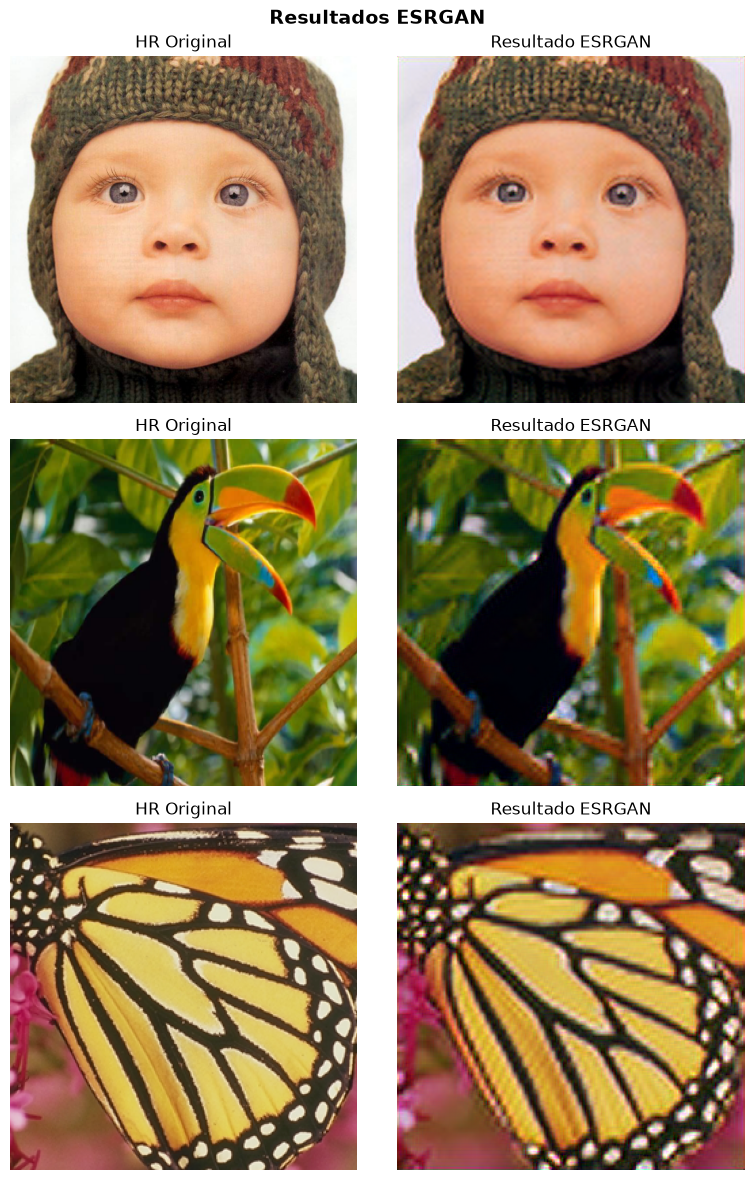

In [8]:
def visualize_esrgan_results(loader, model_esrgan, title, device, n_samples=3):
    fig, axes = plt.subplots(n_samples, 2, figsize=(8, 4 * n_samples))
    model_esrgan.eval()
    
    with torch.no_grad():
        for i, (lr_img, hr_img) in enumerate(loader):
            if i >= n_samples: break
            
            lr_img, hr_img = lr_img.to(device), hr_img.to(device)
            sr_esrgan = model_esrgan(lr_img).clamp(0, 1)
            
            img_hr_np = hr_img[0].permute(1, 2, 0).cpu().numpy()
            img_sr_np = sr_esrgan[0].permute(1, 2, 0).cpu().numpy()
            
            axes[i, 0].imshow(img_hr_np)
            axes[i, 0].set_title("HR Original")
            
            axes[i, 1].imshow(img_sr_np)
            axes[i, 1].set_title("Resultado ESRGAN")
            
            for ax in axes[i]: 
                ax.axis("off")
            
    plt.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    return fig

fig_esrgan = visualize_esrgan_results(val_loader, netG, "Resultados ESRGAN", device, n_samples=3)
plt.savefig(output_dir / "esrgan_resultados_finais.png", dpi=150, bbox_inches="tight")
plt.show()

#### Interpolação de modelos

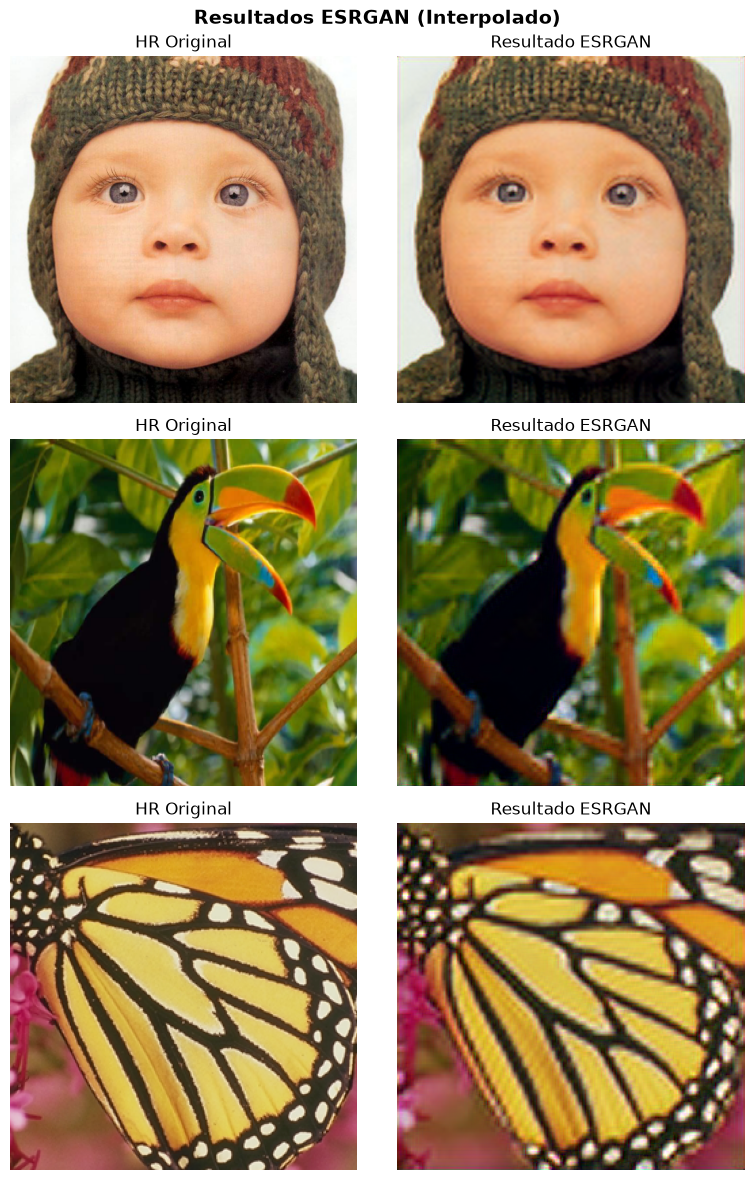

In [ ]:
netG_PSNR = ESRGANGenerator(scale=4).to(device)
netG_PSNR.load_state_dict(torch.load(output_dir / "esrgan_generator_warmup.pth")) # Altere para o caminho do seu warmup

netG_GAN = ESRGANGenerator(scale=4).to(device)
netG_GAN.load_state_dict(torch.load(output_dir / "esrgan_generator_gan.pth"))

netG_interp = ESRGANGenerator(scale=4).to(device)
alpha = 0.8 # Proporção recomendada pelo artigo (80% GAN, 20% PSNR)

state_dict_PSNR = netG_PSNR.state_dict()
state_dict_GAN = netG_GAN.state_dict()
state_dict_interp = netG_interp.state_dict()

for key in state_dict_interp.keys():
    state_dict_interp[key] = (1 - alpha) * state_dict_PSNR[key] + alpha * state_dict_GAN[key]

netG_interp.load_state_dict(state_dict_interp)
torch.save(netG_interp.state_dict(), output_dir / "esrgan_final_interpolated.pth")

fig_interp = visualize_esrgan_results(val_loader, netG_interp, "Resultados ESRGAN (Interpolado)", device, n_samples=3)
plt.show()